In [ ]:


import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
dataset_path = "comp1804_coursework_dataset_24-25.csv"
df = pd.read_csv(dataset_path)



,petition_ID,has_entity,relevant_department,deviation_across_regions,petition_status,petition_topic,petition_importance,petition_text
0,607158,EVENT:NO_DATE:NO_PERSON:NO_,Department for Education,0.000137,unsuccessful,education,not_important,Ban school uniforms in English schools. I want...
1,590629,EVENT:NO_DATE:YES_PERSON:NO_,Department of Health and Social Care,0.002133,unsuccessful,uk government and devolution,important,Lock NHS pay rises to increases in pay for MPs...
2,652724,EVENT:NO_DATE:NO_PERSON:NO_,Department of Health and Social Care,0.000272,unsuccessful,health and social care,important,Require dose counters on SABA metered dose inh...
3,629281,EVENT:NO_DATE:NO_PERSON:NO_,HM Treasury,0.000083,unsuccessful,"economy, labour and welfare",not_important,Remove the 20% VAT on private dementia day car...
4,301747,EVENT:NO_DATE:NO_PERSON:NO_,NaN,NaN,rejected,"culture, sport and media",not_important,Make bank holidays a holiday. Make bank holida...


# Data Evaluation and Assessment

In [ ]:
# Display first few rows
df.head()

,petition_ID,has_entity,relevant_department,deviation_across_regions,petition_status,petition_topic,petition_importance,petition_text
0,607158,EVENT:NO_DATE:NO_PERSON:NO_,Department for Education,0.000137,unsuccessful,education,not_important,Ban school uniforms in English schools. I want...
1,590629,EVENT:NO_DATE:YES_PERSON:NO_,Department of Health and Social Care,0.002133,unsuccessful,uk government and devolution,important,Lock NHS pay rises to increases in pay for MPs...
2,652724,EVENT:NO_DATE:NO_PERSON:NO_,Department of Health and Social Care,0.000272,unsuccessful,health and social care,important,Require dose counters on SABA metered dose inh...
3,629281,EVENT:NO_DATE:NO_PERSON:NO_,HM Treasury,0.000083,unsuccessful,"economy, labour and welfare",not_important,Remove the 20% VAT on private dementia day car...
4,301747,EVENT:NO_DATE:NO_PERSON:NO_,NaN,NaN,rejected,"culture, sport and media",not_important,Make bank holidays a holiday. Make bank holida...


In [ ]:
print(df.shape)

(8898, 8)


In [ ]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8898 entries, 0 to 8897
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   petition_ID               8898 non-null   int64  
 1   has_entity                8898 non-null   object 
 2   relevant_department       7099 non-null   object 
 3   deviation_across_regions  7321 non-null   float64
 4   petition_status           8898 non-null   object 
 5   petition_topic            8867 non-null   object 
 6   petition_importance       20 non-null     object 
 7   petition_text             8896 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 556.3+ KB


In [ ]:
# 3. Data Quality
print("\n### 3. Data Quality ###")
print(df.isnull().sum())


### 3. Data Quality ###
petition_ID                    0
has_entity                     0
relevant_department         1799
deviation_across_regions    1577
petition_status                0
petition_topic                31
petition_importance         8878
petition_text                  2
dtype: int64


In [ ]:
# Data Cleaning
# Drop rows with missing target labels or missing text since these are crucial
df.dropna(subset=['petition_topic', 'petition_text'], inplace=True)

# Text Preprocessing
def clean_text(text):
    text = text.lower()                               # Lowercase
    text = re.sub(r'\[.*?\]', '', text)            # Remove references like [1]
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>+', '', text)                # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()          # Remove extra spaces
    return text
# Load dataset
df.dropna(subset=['petition_topic', 'petition_text'], inplace=True)
df['clean_text'] = df['petition_text'].apply(clean_text)
df['petition_topic'] = df['petition_topic'].str.lower()
df.head()



,petition_ID,has_entity,relevant_department,deviation_across_regions,petition_status,petition_topic,petition_importance,petition_text,clean_text
0,607158,EVENT:NO_DATE:NO_PERSON:NO_,Department for Education,0.000137,unsuccessful,education,not_important,Ban school uniforms in English schools. I want...,ban school uniforms in english schools i want ...
1,590629,EVENT:NO_DATE:YES_PERSON:NO_,Department of Health and Social Care,0.002133,unsuccessful,uk government and devolution,important,Lock NHS pay rises to increases in pay for MPs...,lock nhs pay rises to increases in pay for mps...
2,652724,EVENT:NO_DATE:NO_PERSON:NO_,Department of Health and Social Care,0.000272,unsuccessful,health and social care,important,Require dose counters on SABA metered dose inh...,require dose counters on saba metered dose inh...
3,629281,EVENT:NO_DATE:NO_PERSON:NO_,HM Treasury,0.000083,unsuccessful,"economy, labour and welfare",not_important,Remove the 20% VAT on private dementia day car...,remove the vat on private dementia day care ce...
4,301747,EVENT:NO_DATE:NO_PERSON:NO_,NaN,NaN,rejected,"culture, sport and media",not_important,Make bank holidays a holiday. Make bank holida...,make bank holidays a holiday make bank holiday...


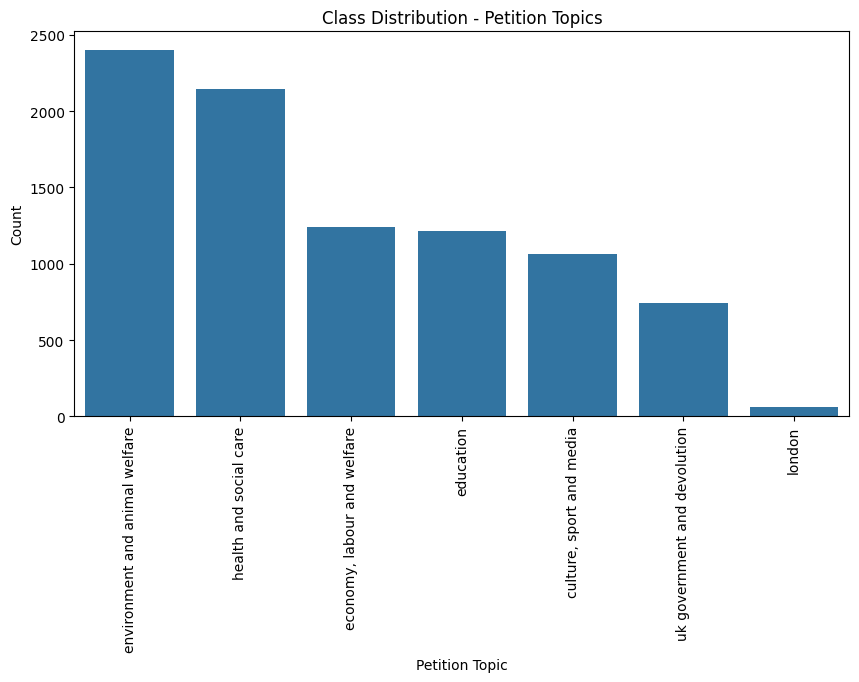

In [ ]:
#EDA - Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='petition_topic', order=df['petition_topic'].value_counts().index) # Change y to x
plt.title('Class Distribution - Petition Topics')
plt.xlabel('Petition Topic')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

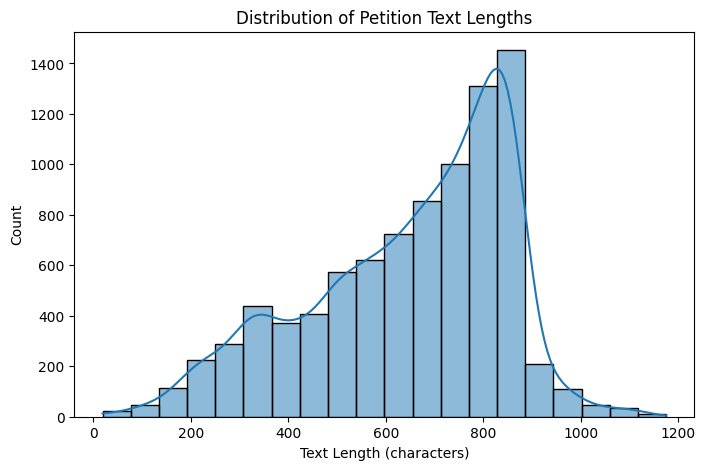

In [ ]:
# EDA - Text Length Distribution
df['text_length'] = df['petition_text'].apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(df['text_length'], bins=20, kde=True)
plt.title('Distribution of Petition Text Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Count')
plt.show()

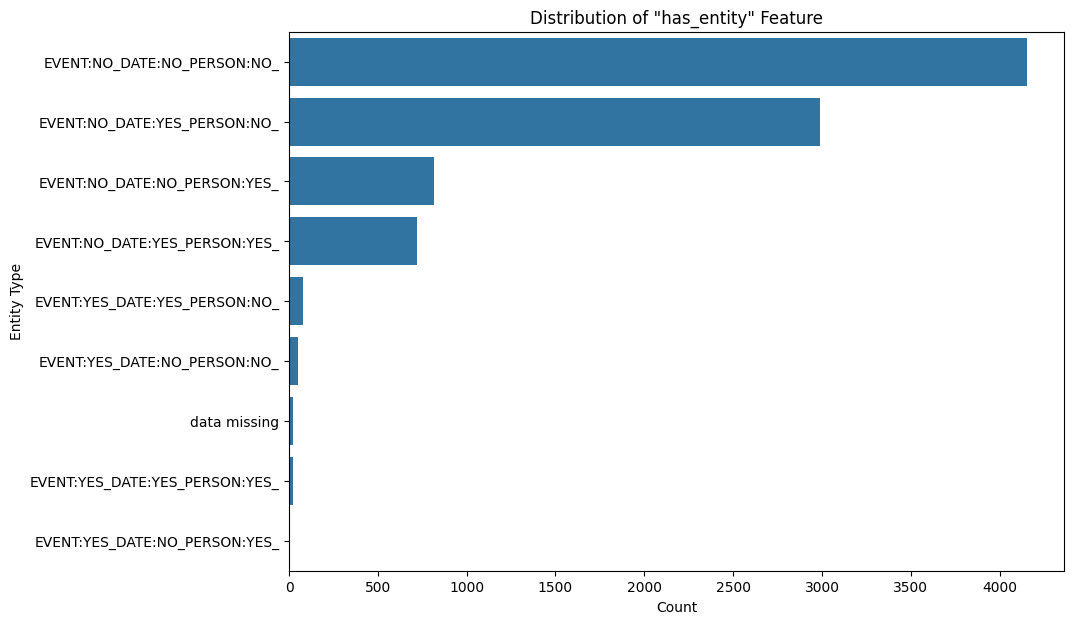

In [ ]:
# EDA - `has_entity` Feature Distribution
plt.figure(figsize=(10, 7))
sns.countplot(data=df, y='has_entity', order=df['has_entity'].value_counts().index)
plt.title('Distribution of "has_entity" Feature')
plt.xlabel('Count')
plt.ylabel('Entity Type')
plt.show()

In [ ]:
#Handle Class Imbalance
max_class_size = df['petition_topic'].value_counts().max()
df_balanced = pd.DataFrame()
for topic in df['petition_topic'].unique():
    class_subset = df[df['petition_topic'] == topic]
    upsampled = resample(class_subset, replace=True, n_samples=max_class_size, random_state=42)
    df_balanced = pd.concat([df_balanced, upsampled])


In [ ]:
#Feature Engineering
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
df_balanced['has_entity_encoded'] = LabelEncoder().fit_transform(df_balanced['has_entity'])
X_text_balanced = vectorizer.fit_transform(df_balanced['clean_text'])
X_balanced = np.hstack((X_text_balanced.toarray(), df_balanced[['has_entity_encoded']].values))

y_balanced = LabelEncoder().fit_transform(df_balanced['petition_topic'])


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)

# Train the SVM Classifier
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Model Evaluation
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [ ]:
# Overfitting Check
y_train_pred = svm_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

In [ ]:
#  Misclassification Analysis
conf_matrix = confusion_matrix(y_test, y_pred)
class_misclassification_rates = []
for i, class_name in enumerate(LabelEncoder().fit(df_balanced['petition_topic']).classes_):
    total_samples = conf_matrix[i].sum()
    correct_predictions = conf_matrix[i][i]
    misclassification_rate = (total_samples - correct_predictions) / total_samples
    class_misclassification_rates.append((class_name, misclassification_rate))

valid_classes = [cls[0] for cls in class_misclassification_rates if cls[1] <= 0.13]
uk_gov_index = list(LabelEncoder().fit(df_balanced['petition_topic']).classes_).index('uk government and devolution')
uk_gov_misclassification_rate = (conf_matrix[uk_gov_index].sum() - conf_matrix[uk_gov_index][uk_gov_index]) / conf_matrix[uk_gov_index].sum()

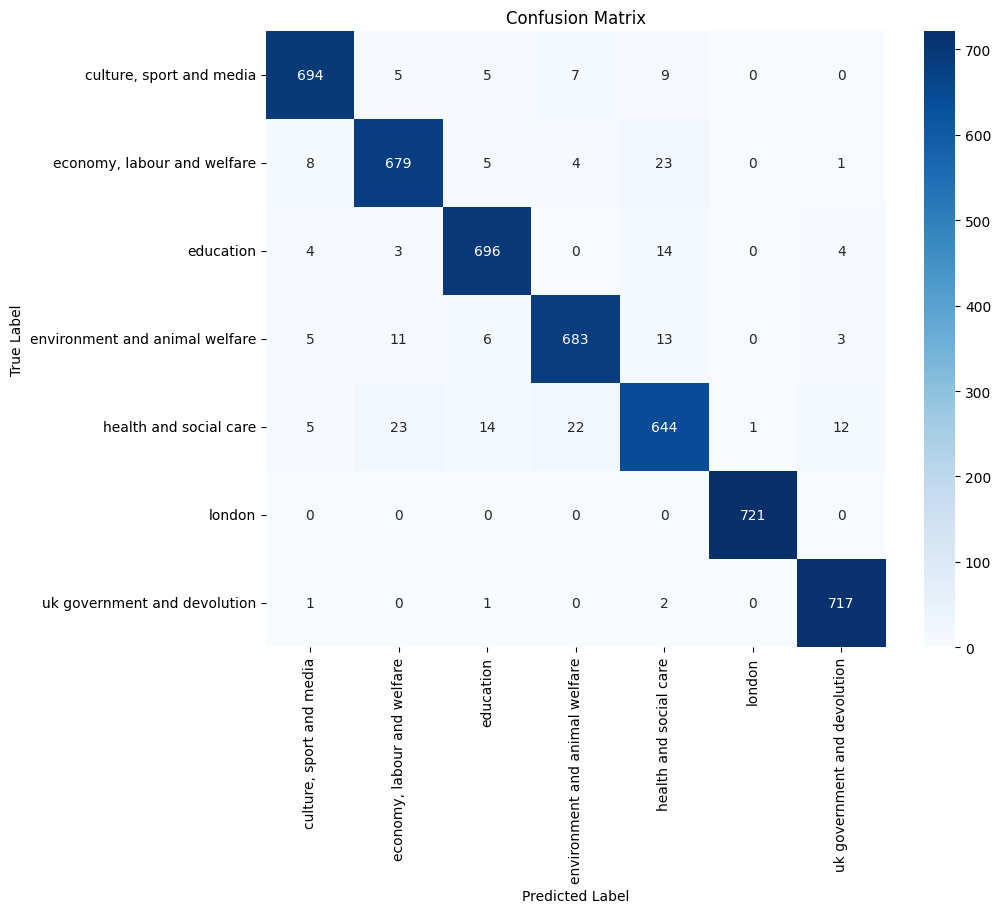

In [ ]:
# Plot Confusion Matrix
label_encoder = LabelEncoder().fit(df_balanced['petition_topic'])
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:

# Display Results
print("### Task 1 Results ###\n")
print(f"1) Test Accuracy: {accuracy:.2%} (Meets the ≥ 86% requirement)")
print(f"2) Training Accuracy: {train_accuracy:.2%}")
print(f"   Test Accuracy: {accuracy:.2%}")
if abs(train_accuracy - accuracy) < 0.05:
    print("  **No overfitting detected**")
else:
    print("  **Overfitting detected**")

print(f"3) Classes with ≤ 13% misclassification rate: {', '.join(valid_classes)}")
print(f"   {len(valid_classes)} out of 7 classes meet this condition.")
print(f"4) Misclassification Rate for 'uk government and devolution': {uk_gov_misclassification_rate:.2%}")
if uk_gov_misclassification_rate < 0.09:
    print("  Meets the requirement of ≤ 9%")
else:
    print("  Does not meet the requirement.")


### Task 1 Results ###

1) Test Accuracy: 95.82% (Meets the ≥ 86% requirement)
2) Training Accuracy: 98.85%
   Test Accuracy: 95.82%
  **No overfitting detected**
3) Classes with ≤ 13% misclassification rate: culture, sport and media, economy, labour and welfare, education, environment and animal welfare, health and social care, london, uk government and devolution
   7 out of 7 classes meet this condition.
4) Misclassification Rate for 'uk government and devolution': 0.55%
  Meets the requirement of ≤ 9%


In [ ]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       720
           1       0.94      0.94      0.94       720
           2       0.96      0.97      0.96       721
           3       0.95      0.95      0.95       721
           4       0.91      0.89      0.90       721
           5       1.00      1.00      1.00       721
           6       0.97      0.99      0.98       721

    accuracy                           0.96      5045
   macro avg       0.96      0.96      0.96      5045
weighted avg       0.96      0.96      0.96      5045

